# Taller interactivo: Transformacion de una casa en $R^3$

En este taller veremos como una matriz de transformacion lineal en $\mathbb{R}^3$ cambia la forma y la orientacion de una casa 3D.

Objetivos:
- Representar una casa en 3D mediante vertices y aristas.
- Aplicar una matriz $A\in\mathbb{R}^{3\times 3}$ a todos los puntos.
- Explorar reflexiones hacia distintos octantes usando matrices diagonales con signos.
- Manipular la matriz y observar el efecto grafico en tiempo real.

## Recordatorio teorico
Si $v$ es un punto de la casa, su transformacion es:
$$
T(v)=Av
$$
donde $A$ es una matriz $3\times 3$.

Reflexiones tipicas:
- Respecto al plano $yz$: $\mathrm{diag}(-1,1,1)$
- Respecto al plano $xz$: $\mathrm{diag}(1,-1,1)$
- Respecto al plano $xy$: $\mathrm{diag}(1,1,-1)$
- Respecto al origen: $-I$

In [1]:
#%pip install ipympl
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

%matplotlib widget

In [2]:
# Vertices de una casa en 3D
V = np.array([
    [0.0, 0.0, 0.0],  # 0 base
    [2.0, 0.0, 0.0],  # 1
    [2.0, 2.0, 0.0],  # 2
    [0.0, 2.0, 0.0],  # 3
    [0.0, 0.0, 1.0],  # 4 techo base
    [2.0, 0.0, 1.0],  # 5
    [2.0, 2.0, 1.0],  # 6
    [0.0, 2.0, 1.0],  # 7
    [1.0, 0.0, 1.8],  # 8 cumbrera frente
    [1.0, 2.0, 1.8],  # 9 cumbrera fondo
])

# Aristas (pares de indices de vertices)
E = [
    (0, 1), (1, 2), (2, 3), (3, 0),
    (0, 4), (1, 5), (2, 6), (3, 7),
    (4, 5), (5, 6), (6, 7), (7, 4),
    (4, 8), (5, 8), (7, 9), (6, 9),
    (8, 9)
]

def aplicar_transformacion(A, puntos):
    return (A @ puntos.T).T

def dibujar_casa(ax, puntos, color='tab:blue', titulo='Casa'):
    for i, j in E:
        x = [puntos[i, 0], puntos[j, 0]]
        y = [puntos[i, 1], puntos[j, 1]]
        z = [puntos[i, 2], puntos[j, 2]]
        ax.plot(x, y, z, color=color, linewidth=2)

    ax.scatter(puntos[:, 0], puntos[:, 1], puntos[:, 2], color=color, s=25)
    ax.set_title(titulo)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_box_aspect((1, 1, 1))

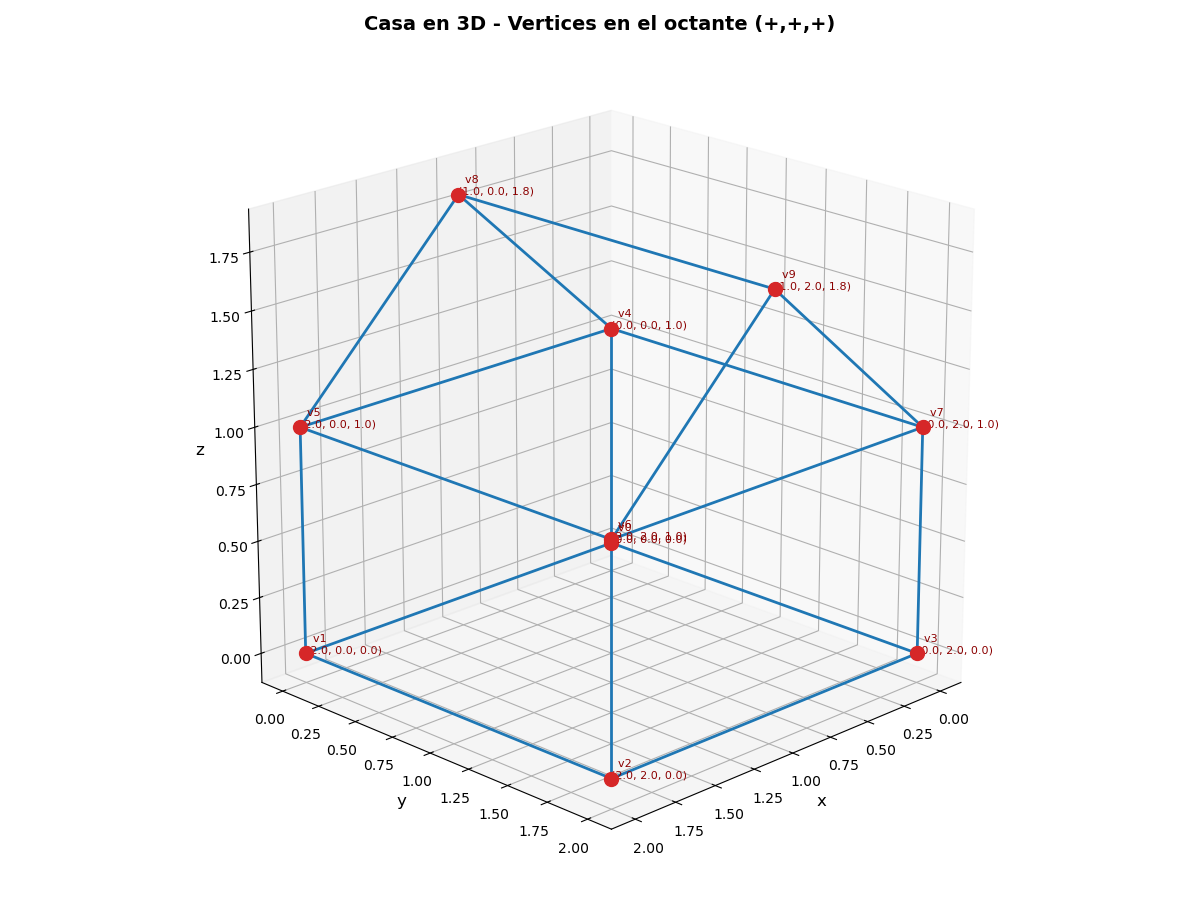

In [3]:
# Visualizacion estatica de la casa con puntos etiquetados
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Dibujar la casa
for i, j in E:
    x = [V[i, 0], V[j, 0]]
    y = [V[i, 1], V[j, 1]]
    z = [V[i, 2], V[j, 2]]
    ax.plot(x, y, z, color='tab:blue', linewidth=2)

# Dibujar puntos con etiquetas y coordenadas
for idx, point in enumerate(V):
    ax.scatter(*point, color='tab:red', s=100, zorder=5)
    coord_text = f'v{idx}\n({point[0]:.1f}, {point[1]:.1f}, {point[2]:.1f})'
    ax.text(point[0], point[1], point[2], f'  {coord_text}', fontsize=8, color='darkred')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('z', fontsize=12)
ax.set_title('Casa en 3D - Vertices en el octante (+,+,+)', fontsize=14, fontweight='bold')
ax.view_init(elev=20, azim=45)
ax.grid(True, alpha=0.3)
ax.set_box_aspect((1, 1, 1))
plt.tight_layout()
plt.show()

In [4]:
# Widgets para editar la matriz A (solo para la casa)
a11 = widgets.FloatText(value=1.0, description='a11')
a12 = widgets.FloatText(value=0.0, description='a12')
a13 = widgets.FloatText(value=0.0, description='a13')
a21 = widgets.FloatText(value=0.0, description='a21')
a22 = widgets.FloatText(value=1.0, description='a22')
a23 = widgets.FloatText(value=0.0, description='a23')
a31 = widgets.FloatText(value=0.0, description='a31')
a32 = widgets.FloatText(value=0.0, description='a32')
a33 = widgets.FloatText(value=1.0, description='a33')

def matriz_actual():
    return np.array([
        [a11.value, a12.value, a13.value],
        [a21.value, a22.value, a23.value],
        [a31.value, a32.value, a33.value],
    ], dtype=float)

# Octantes por signos (x, y, z)
octantes = {
    '(+,+,+)': ( 1,  1,  1),
    '(-,+,+)': (-1,  1,  1),
    '(+,-,+)': ( 1, -1,  1),
    '(+,+,-)': ( 1,  1, -1),
    '(-,-,+)': (-1, -1,  1),
    '(-,+,-)': (-1,  1, -1),
    '(+,-,-)': ( 1, -1, -1),
    '(-,-,-)': (-1, -1, -1),
}

selector_octante = widgets.Dropdown(
    options=list(octantes.keys()),
    value='(+,+,+)',
    description='Octante:'
)

btn_reflexion = widgets.Button(description='Cargar reflexion al octante', button_style='info')
btn_aplicar = widgets.Button(description='Aplicar y graficar', button_style='success')
salida = widgets.Output()

def cargar_reflexion(_):
    sx, sy, sz = octantes[selector_octante.value]
    a11.value, a12.value, a13.value = sx, 0.0, 0.0
    a21.value, a22.value, a23.value = 0.0, sy, 0.0
    a31.value, a32.value, a33.value = 0.0, 0.0, sz

def graficar(_=None):
    A = matriz_actual()
    VT = aplicar_transformacion(A, V)
    detA = np.linalg.det(A)

    with salida:
        clear_output(wait=True)
        fig = plt.figure(figsize=(12, 5))

        ax1 = fig.add_subplot(121, projection='3d')
        dibujar_casa(ax1, V, color='tab:blue', titulo='Casa original')

        ax2 = fig.add_subplot(122, projection='3d')
        dibujar_casa(ax2, VT, color='tab:red', titulo='Casa transformada')

        all_pts = np.vstack([V, VT])
        lim = np.max(np.abs(all_pts)) + 0.5
        for ax in (ax1, ax2):
            ax.set_xlim([-lim, lim])
            ax.set_ylim([-lim, lim])
            ax.set_zlim([-lim, lim])
            ax.view_init(elev=20, azim=35)
            ax.grid(True, alpha=0.35)

        plt.tight_layout()
        plt.show()

        print('Matriz A usada:')
        print(A)
        print(f'det(A) = {detA:.3f}')
        if detA < 0:
            print('Interpretacion: hay cambio de orientacion (incluye una reflexion).')
        elif detA == 0:
            print('Interpretacion: la transformacion colapsa dimensiones (no es invertible).')
        else:
            print('Interpretacion: conserva orientacion (sin reflexion pura).')

btn_reflexion.on_click(cargar_reflexion)
btn_aplicar.on_click(graficar)

fila1 = widgets.HBox([a11, a12, a13])
fila2 = widgets.HBox([a21, a22, a23])
fila3 = widgets.HBox([a31, a32, a33])
controles = widgets.VBox([
    widgets.HTML('<b>Matriz de transformacion A (para la casa)</b>'),
    fila1, fila2, fila3,
    selector_octante,
    widgets.HBox([btn_reflexion, btn_aplicar])
])

display(controles, salida)

# Grafica inicial
graficar()

Output()

## Actividades propuestas

### Sección 1: Ejercicio de la Casa

#### Parte 1A: Reflexiones y Determinante
1. **Reflexiones**: Carga la reflexión hacia cada octante usando el botón "Cargar reflexión". Describe qué coordenadas cambian de signo en cada caso. ¿Qué relación existe entre el octante elegido y los signos en la diagonal de $A$?

2. **Determinante y orientación**: Calcula $\det(A)$ para cada reflexión. Observa el signo del determinante. ¿Qué patrón encuentras? ¿Cómo se relaciona el signo del determinante con la orientación de la casa?

#### Parte 1B: Transformaciones especiales
3. **Cizalla**: Ingresa una matriz de cizalla, por ejemplo $A = \begin{pmatrix} 1 & 1 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}$.
   - ¿Qué transformación realiza en la casa?
   - ¿Cuánto vale $\det(A)$? ¿Es invertible?

4. **Escalamiento**: Usa $A = \mathrm{diag}(2, 1.5, 0.8)$.
   - ¿Qué ocurre con la casa?
   - ¿Cómo cambia el signo de $\det(A)$?

#### Parte 1C: Síntesis
5. **Invertibilidad**: Encuentra una matriz que sea **invertible** y desplace la casa al octante $(-,-,+)$ sin colapsar la figura. Verifica que $\det(A) \neq 0$.

6. **Recuperación**: Una vez aplicada una transformación invertible, ¿cómo recuperarías la casa original? Describe el procedimiento y prueba ingresando manualmente los valores de $A^{-1}$.

---


---

# Sección 2: Criptografía con Transformaciones Lineales — Cifrado de Hill

## ¿Cómo funciona?

El **cifrado de Hill** es un método de encriptación que convierte un mensaje de texto en vectores numéricos y los transforma usando una **multiplicación de matrices**. Así, la misma operación $T(\mathbf{v}) = A\mathbf{v}$ que usamos para mover la casa en 3D, aquí se usa para **ocultar información**.

---

### Paso 1 — Convertir letras en números

Antes de aplicar cualquier operación matemática necesitamos representar el texto como números. Usamos el siguiente diccionario:

| A | B | C | D | E | F | G | H | I | J | K | L | M | N | O | P | Q | R | S | T | U | V | W | X | Y | Z | (espacio) |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|-----------|
| 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |10 |11 |12 |13 |14 |15 |16 |17 |18 |19 |20 |21 |22 |23 |24 |25 | 26 |

Tenemos **27 símbolos** en total (26 letras + espacio). Por eso trabajamos con el número 27.

**Ejemplo**: `HOLA` → `[7, 14, 11, 0]`

---

### Paso 2 — Dividir el mensaje en bloques de 3

Agrupamos los números de 3 en 3 para formar **vectores de dimensión 3** (igual que los puntos de la casa en $\mathbb{R}^3$):

$$
\text{"HOLA MUNDO"} \;\longrightarrow\; \underbrace{[7,\,14,\,11]}_{\text{HOL}},\; \underbrace{[0,\,26,\,12]}_{\text{A M}},\; \underbrace{[20,\,13,\,3]}_{\text{UND}},\; \underbrace{[14,\,26,\,26]}_{\text{O\,\_\,\_}}
$$

*(Si el mensaje no es múltiplo de 3, se rellena con espacios al final.)*

---

### Paso 3 — Cifrar: aplicar la transformación lineal

Cada bloque $\mathbf{v}$ se transforma con la matriz clave $A$:

$$
\mathbf{c} = A\,\mathbf{v} \pmod{27}
$$

El símbolo **mod 27** es como el "resto de dividir entre 27". Por ejemplo: $30 \bmod 27 = 3$ (porque $30 = 1 \times 27 + 3$). Esto nos sirve para que el resultado siempre sea un número entre 0 y 26, es decir, **siempre corresponda a una letra o espacio válido**.

> **Analogía**: es como una ruleta de 27 posiciones — si nos pasamos del 26, damos la vuelta y seguimos contando desde el 0.

**Ejemplo con un bloque**:
$$
A \begin{pmatrix}7\\14\\11\end{pmatrix} = \begin{pmatrix}149\\323\\411\end{pmatrix} \xrightarrow{\bmod 27} \begin{pmatrix}14\\26\\6\end{pmatrix} \;\longrightarrow\; \text{"O G"}
$$

El texto cifrado **parece completamente aleatorio** — nadie puede leerlo sin conocer la clave $A$.

---

### Paso 4 — Descifrar: aplicar la transformación inversa

Para recuperar el mensaje original, quien recibe el texto cifrado aplica la transformación **inversa**:

$$
\mathbf{v} = A^{-1}\,\mathbf{c} \pmod{27}
$$

Aquí es donde entra la **invertibilidad**: si la matriz $A$ no es invertible, $A^{-1}$ no existe y el mensaje se pierde para siempre.

**¿Cuándo existe $A^{-1}$ cuando trabajamos mod 27?**

En aritmética normal, una fracción como $\frac{1}{5}$ siempre existe. Pero cuando solo podemos usar **números enteros** (0, 1, 2, …, 26), dividir no siempre es posible. En particular, el descifrado requiere "dividir por $\det(A)$" en el mundo de los enteros mod 27.

Esto solo es posible si $\det(A)$ y 27 **no comparten factores en común**. La herramienta calcula automáticamente el **máximo común divisor** (mcd) entre $\det(A)$ y 27:

- **mcd($\det(A)$, 27) = 1** → los números no comparten factores → $A^{-1}$ existe → ✔ se puede descifrar
- **mcd($\det(A)$, 27) ≠ 1** → comparten algún factor → $A^{-1}$ no existe → ✘ mensaje irrecuperable

> **Recordatorio**: el máximo común divisor (mcd) de dos números es el mayor número que divide a ambos exactamente.  
> Ejemplos: mcd(6, 4) = 2 — mcd(9, 27) = 9 — mcd(5, 27) = 1 (5 y 27 no tienen factores en común).

Como $27 = 3^3$, basta con verificar que $\det(A)$ **no sea múltiplo de 3** para garantizar que el cifrado es reversible.

---

### Conexión con el taller

| Sección anterior | Cifrado de Hill |
|------------------|-----------------|
| Casa en $\mathbb{R}^3$ | Bloque de 3 letras como vector |
| Transformación $T(\mathbf{v}) = A\mathbf{v}$ | Cifrado $\mathbf{c} = A\mathbf{v} \bmod 27$ |
| $A$ invertible → casa recuperable | mcd($\det A$, 27) = 1 → mensaje descifrable |
| Rango < 3 → casa colapsa | mcd($\det A$, 27) ≠ 1 → mensaje irrecuperable |

---

### Actividades

1. Escribe un mensaje y cífralo con la clave por defecto. Anota el texto cifrado.
2. Verifica que al presionar **Descifrar** recuperas el mensaje original exacto.
3. Modifica la matriz $A$ a una **no invertible** (ej. pon una fila entera en ceros, o copia la fila 1 en la fila 2). ¿Qué ocurre al intentar descifrar?
4. Prueba ingresar la matriz identidad $I$ como clave. ¿Qué esperas que pase? ¿Por qué?
5. ¿Por qué un atacante que intercepta el texto cifrado no puede leerlo fácilmente si no conoce $A$?


In [ ]:

# =======================================================================
#  CIFRADO DE HILL — Transformación lineal sobre Z_27
#  Alfabeto: A-Z (0-25) + espacio (26)  →  módulo 27
#  Bloques de 3 caracteres = vectores en Z_27^3
# =======================================================================

MOD = 27   # módulo = tamaño del alfabeto (26 letras + espacio)

ALFA = "ABCDEFGHIJKLMNOPQRSTUVWXYZ "   # posición = código numérico
1
def texto_a_nums(texto):
    """Convierte texto a lista de enteros (0-26). Ignora caracteres fuera del alfabeto."""
    texto = texto.upper()
    nums = []
    for c in texto:
        if c in ALFA:
            nums.append(ALFA.index(c))
    return nums

def nums_a_texto(nums):
    return "".join(ALFA[n % MOD] for n in nums)

def cifrar_hill(texto, A):
    """Cifra 'texto' usando la clave A (matriz 3×3 entera) módulo 27."""
    nums = texto_a_nums(texto)
    # Rellenar con espacios hasta múltiplo de 3
    while len(nums) % 3 != 0:
        nums.append(26)   # 26 = espacio
    A_mod = np.array(A, dtype=int) % MOD
    cifrado = []
    for i in range(0, len(nums), 3):
        bloque = np.array(nums[i:i+3])
        cifrado.extend((A_mod @ bloque) % MOD)
    return nums_a_texto(cifrado)

def inversa_mod(A, mod):
    """Calcula A^{-1} mod 'mod' usando la fórmula de la adjunta."""
    det = int(round(np.linalg.det(A))) % mod
    # Inverso modular del determinante (requiere gcd(det, mod) = 1)
    try:
        det_inv = pow(det, -1, mod)
    except ValueError:
        return None    # No exis1te inversa
    # Adjunta clásica (cofactores)
    A = np.array(A, dtype=int)
    n = 3
    adj = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            minor = np.delete(np.delete(A, i, axis=0), j, axis=1)
            adj[j, i] = ((-1) ** (i + j)) * int(round(np.linalg.det(minor)))
    return (det_inv * adj) % mod

def descifrar_hill(texto_cifrado, A):
    """Descifra usando A^{-1} mod 27."""
    Ainv = inversa_mod(A, MOD)
    if Ainv is None:
        return None
    return cifrar_hill(texto_cifrado, Ainv)

# ---- Widgets ----------------------------------------------------------
# Clave por defecto: invertible mod 27
clave_defecto = [[6, 24, 1],1
                 [13, 16, 10],
                 [20, 17, 15]]

k_entries = [[widgets.IntText(value=clave_defecto[i][j],
                              layout=widgets.Layout(width='60px'))
              for j in range(3)] for i in range(3)]

txt_entrada  = widgets.Textarea(value='HOLA MUNDO',
                                description='Mensaje:',
                                layout=widgets.Layout(width='400px', height='60px'))
txt_cifrado  = widgets.Textarea(description='Cifrado:',
                                disabled=True,
                                layout=widgets.Layout(width='400px', height='60px'))
txt_descif   = widgets.Textarea(description='Descifrado:',
                                disabled=True,
                                layout=widgets.Layout(width='400px', height='60px'))

lbl_det      = widgets.HTML(value='')
lbl_inv      = widgets.HTML(value='')

btn_cifrar   = widgets.Button(description='Cifrar',   button_style='primary')
btn_descifrar = widgets.Button(description='Descifrar', button_style='warning')
btn_limpiar  = widgets.Button(description='Limpiar',   button_style='danger')

salida_cripto = widgets.Output()

def get_clave():
    return [[k_entries[i][j].value for j in range(3)] for i in range(3)]

def actualizar_info(_=None):
    A = np.array(get_clave(), dtype=int)
    det = int(round(np.linalg.det(A))) % MOD
    from math import gcd
    es_inv = gcd(det, MOD) == 1
    Ainv   = inversa_mod(A, MOD)
    lbl_det.value = (
        f"<b>det(A) mod 27 = {det}</b> &nbsp;|&nbsp; "
        f"mcd(det, 27) = {gcd(det, MOD)} &nbsp;|&nbsp; "
        f"<span style='color:{'green' if es_inv else 'red'}'>"
        f"{'✔ Invertible mod 27' if es_inv else '✘ NO invertible — no se puede descifrar'}"
        f"</span>"
    )
    if Ainv is not None:
        lbl_inv.value = (
            "<b>A⁻¹ mod 27:</b><br>"
            + "<br>".join(["  [" + "  ".join(f"{v:3d}" for v in row) + "]"
                           for row in Ainv.tolist()])
        )
    else:
        lbl_inv.value = "<span style='color:red'>A no tiene inversa mod 27.</span>"

def on_cifrar(_):
    with salida_cripto:
        clear_output(wait=True)
    A = np.array(get_clave(), dtype=int)
    c = cifrar_hill(txt_entrada.value, A)
    txt_cifrado.value = c
    txt_descif.value = ''
    actualizar_info()

def on_descifrar(_):
    with salida_cripto:
        clear_output(wait=True)
    A = np.array(get_clave(), dtype=int)
    fuente = txt_cifrado.value if txt_cifrado.value.strip() else txt_entrada.value
    d = descifrar_hill(fuente, A)
    if d is None:
        txt_descif.value = '⚠ La matriz A no es invertible mod 27. No se puede descifrar.'
    else:
        txt_descif.value = d
    actualizar_info()

def on_limpiar(_):
    txt_cifrado.value = ''
    txt_descif.value  = ''
    lbl_det.value     = ''
    lbl_inv.value     = ''

btn_cifrar.on_click(on_cifrar)
btn_descifrar.on_click(on_descifrar)
btn_limpiar.on_click(on_limpiar)

# Actualizar info al cambiar cualquier celda de la clave
for i in range(3):
    for j in range(3):
        k_entries[i][j].observe(actualizar_info, names='value')

# Layout
filas_clave = [widgets.HBox(k_entries[i]) for i in range(3)]
panel_clave = widgets.VBox([
    widgets.HTML('<b>Clave A (matriz 3×3 de enteros):</b>'),
    *filas_clave,
    lbl_det,
    lbl_inv
])

panel_msg = widgets.VBox([
    txt_entrada,
    widgets.HBox([btn_cifrar, btn_descifrar, btn_limpiar]),
    txt_cifrado,
    txt_descif,
])

display(widgets.HBox([panel_clave,
                      widgets.HTML('&nbsp;' * 4),
                      panel_msg]),
        salida_cripto)

actualizar_info()


Output()